# 01 · Planning (Plan-and-Execute)

**Idea:** Don't let the model improvise everything in one go. First *plan* (break the task into steps),
then *execute* the steps one by one, then *synthesize* a final answer.

```
START -> planner -> executor --(more steps?)--> executor (loop)
                        |
                        +--(done)--> synthesize -> END
```

**Why it helps:** small models get lost on big tasks; tiny focused steps are far more reliable.
**Use when:** multi-step tasks (research, trip planning, report writing).

In [11]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

In [12]:
import operator
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

# The planner must return a LIST of steps. A pydantic model gives us a guaranteed shape.
class Plan(BaseModel):
    steps: list[str] = Field(description="3 to 4 short, ordered steps to accomplish the task")

class State(TypedDict):
    task: str
    plan: list[str]
    results: Annotated[list[str], operator.add]   # each executed step APPENDS its result
    answer: str

### The three kinds of nodes

In [22]:
class Test:
    val:list[str]=["a","b"]
print(type(H.val),Test.val, *Test.val,sep="\n  - ")

<class 'list'>
  - ['a', 'b']
  - a
  - b


In [23]:
def planner(state: State):
    """Step 1: ask the LLM for a plan (structured output -> a real Python list)."""
    planner_llm = llm.with_structured_output(Plan)
    plan = planner_llm.invoke(f"Break this task into 3-4 short steps. Task: {state['task']}")
    print("📝 PLAN:", *plan.steps, sep="\n  - ")
    return {"plan": plan.steps}


def executor(state: State):
    """Step 2: do ONE step. We know which one by counting results so far."""
    step_no = len(state["results"])
    print("STEP No:",step_no)
    step = state["plan"][step_no]
    print("STEP :",step)
    done_so_far = "\n".join(state["results"]) or "nothing yet"
    print("STEPS DONE :",done_so_far)
    out = llm.invoke(
        f"Overall task: {state['task']}\n"
        f"Already done:\n{done_so_far}\n\n"
        f"Now do ONLY this step, in 2-3 sentences: {step}"
    )
    print(f"⚙️  step {step_no + 1}: {step}")
    print(f"##   step {step_no + 1} Result: {out.content}")
    return {"results": [out.content]}


def synthesize(state: State):
    """Step 3: merge all step results into one final answer."""
    joined = "\n".join(f"- {r}" for r in state["results"])
    out = llm.invoke(f"Task: {state['task']}\nCombine these results into a short final answer:\n{joined}")
    return {"answer": out.content}


def more_steps(state: State):
    """Conditional edge: loop back to executor until every planned step has a result."""
    return "executor" if len(state["results"]) < len(state["plan"]) else "synthesize"

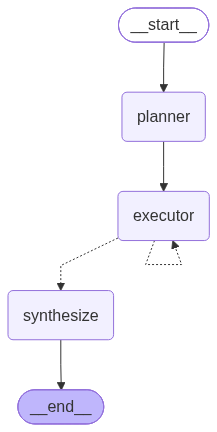

In [24]:
builder = StateGraph(State)
builder.add_node("planner", planner)
builder.add_node("executor", executor)
builder.add_node("synthesize", synthesize)

builder.add_edge(START, "planner")
builder.add_edge("planner", "executor")
builder.add_conditional_edges("executor", more_steps, ["executor", "synthesize"])
builder.add_edge("synthesize", END)

graph = builder.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
result = graph.invoke({"task": "Plan a 2-day budget trip to Puri, India", "results": []})
print("\n✅ FINAL ANSWER:\n", result["answer"])

📝 PLAN:
  - Research and shortlist budget-friendly accommodations in Puri, such as guesthouses or hostels, and book them in advance to ensure availability.
  - Plan the itinerary for the 2-day trip, including visiting the Jagannath Temple, Puri Beach, and other local attractions. Consider the opening hours, ticket prices, and any necessary permissions or reservations.
  - Create a budget for the trip, including transportation costs, food expenses, and any other necessary expenses. Research affordable options for transportation, such as buses or trains, and plan for meals at local eateries or street food stalls.
  - Make a list of essential items to pack, such as comfortable clothing, sunscreen, and a camera, and consider purchasing any necessary travel documents, such as a train ticket or a local SIM card.
STEP No: 0
STEP : Research and shortlist budget-friendly accommodations in Puri, such as guesthouses or hostels, and book them in advance to ensure availability.
STEPS DONE : nothing

### Go further
* **Re-planning:** add a `replanner` node after each step that can edit the remaining plan if a step failed
  (this is the "Plan-and-Execute with replanning" variant).
* **Tools in the executor:** swap the executor's `llm.invoke` for an agent from notebook 09.